In [92]:
import sys
sys.path.insert(0, "src")

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from profiles import Profile, Archetype, WorkArrangement

with open("artifacts/filtered_profiles.json") as file:
    profiles_json = json.load(file)
filtered_profiles = [Profile.model_validate(profile_json) for profile_json in profiles_json]

/var/folders/4w/3bqxxzqx2757wzv44nl1cm7r0000gn/T/ipykernel_9158/3119590974.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(share.index, rotation = 20, ha = "right")


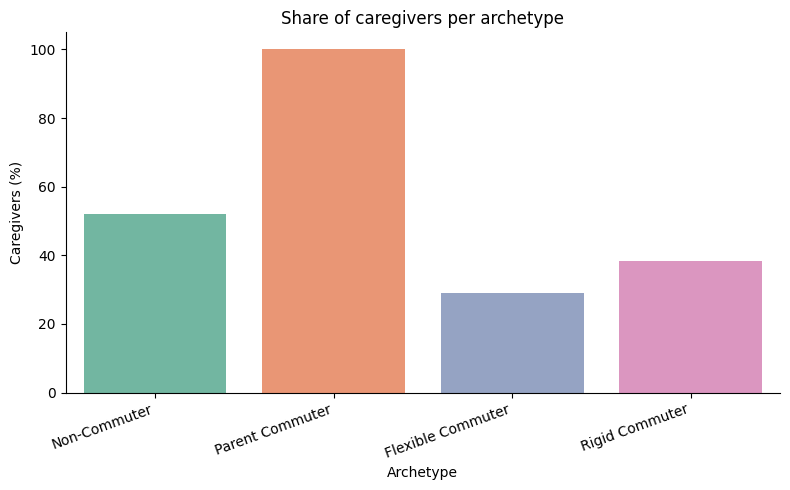

In [93]:
records = [
    {"archetype": profile.archetype.value, "is_caregiver": profile.attributes.is_caregiver}
    for profile in filtered_profiles
]
df = pd.DataFrame(records)

share = df.groupby("archetype")["is_caregiver"].mean().mul(100)
share = share.reindex([archetype.value for archetype in Archetype])

fig, ax = plt.subplots(figsize = (8, 5))
sns.barplot(x = share.index, y = share.values, hue = share.index, palette = "Set2", legend = False, ax = ax)
ax.set_xlabel("Archetype")
ax.set_ylabel("Caregivers (%)")
ax.set_title("Share of caregivers per archetype")
ax.set_xticklabels(share.index, rotation = 20, ha = "right")
sns.despine()
plt.tight_layout()
plt.show()

/var/folders/4w/3bqxxzqx2757wzv44nl1cm7r0000gn/T/ipykernel_9158/1191843338.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mean_trips.index, rotation = 20, ha = "right")


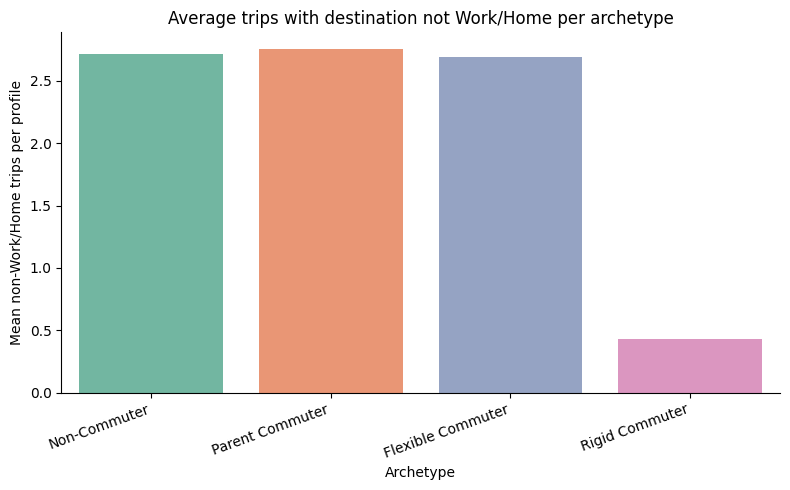

In [94]:
non_routine_records = [
    {
        "archetype": profile.archetype.value,
        "non_routine_trips": sum(1 for trip in profile.trips if trip.dest_activity not in ("Work", "Home"))
    }
    for profile in filtered_profiles
]
non_routine_df = pd.DataFrame(non_routine_records)

mean_trips = non_routine_df.groupby("archetype")["non_routine_trips"].mean()
mean_trips = mean_trips.reindex([archetype.value for archetype in Archetype])

fig, ax = plt.subplots(figsize = (8, 5))
sns.barplot(x = mean_trips.index, y = mean_trips.values, hue = mean_trips.index, palette = "Set2", legend = False, ax = ax)
ax.set_xlabel("Archetype")
ax.set_ylabel("Mean non-Work/Home trips per profile")
ax.set_title("Average trips with destination not Work/Home per archetype")
ax.set_xticklabels(mean_trips.index, rotation = 20, ha = "right")
sns.despine()
plt.tight_layout()
plt.show()

/var/folders/4w/3bqxxzqx2757wzv44nl1cm7r0000gn/T/ipykernel_9158/4192826377.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mean_dropoff.index, rotation = 20, ha = "right")


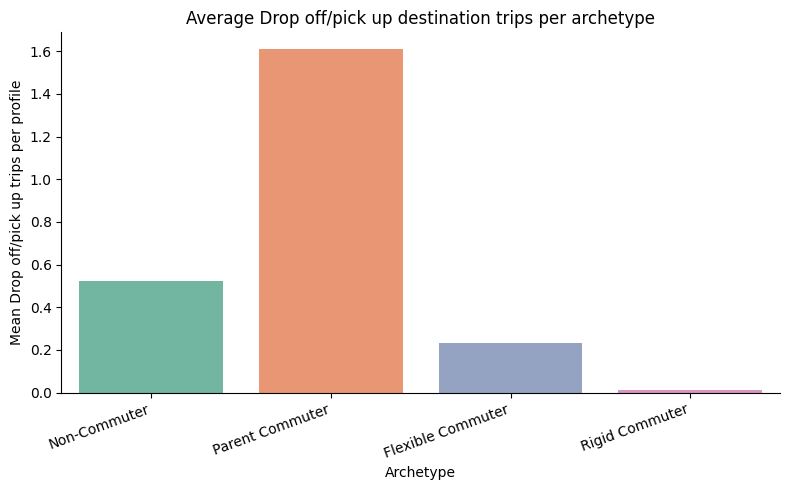

In [95]:
dropoff_records = [
    {
        "archetype": profile.archetype.value,
        "dropoff_trips": sum(1 for trip in profile.trips if trip.dest_activity == "Drop off/pick up")
    }
    for profile in filtered_profiles
]
dropoff_df = pd.DataFrame(dropoff_records)

mean_dropoff = dropoff_df.groupby("archetype")["dropoff_trips"].mean()
mean_dropoff = mean_dropoff.reindex([archetype.value for archetype in Archetype])

fig, ax = plt.subplots(figsize = (8, 5))
sns.barplot(x = mean_dropoff.index, y = mean_dropoff.values, hue = mean_dropoff.index, palette = "Set2", legend = False, ax = ax)
ax.set_xlabel("Archetype")
ax.set_ylabel("Mean Drop off/pick up trips per profile")
ax.set_title("Average Drop off/pick up destination trips per archetype")
ax.set_xticklabels(mean_dropoff.index, rotation = 20, ha = "right")
sns.despine()
plt.tight_layout()
plt.show()

/var/folders/4w/3bqxxzqx2757wzv44nl1cm7r0000gn/T/ipykernel_9158/895283546.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation = 20, ha = "right")


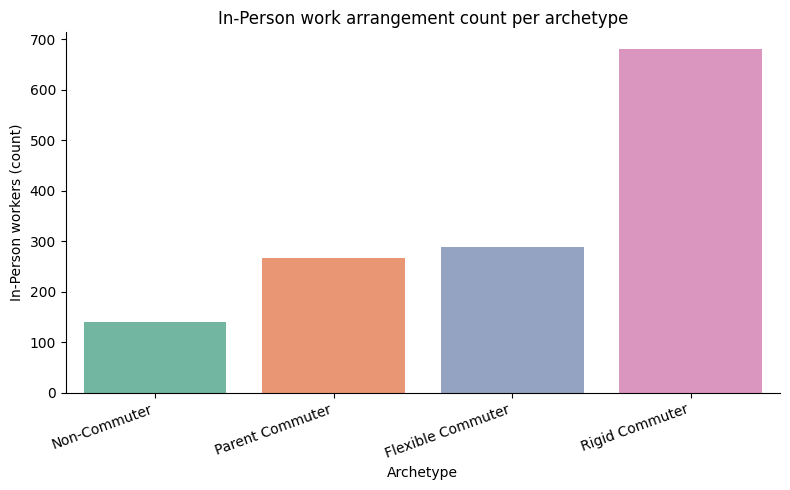

In [96]:
in_person_records = [
    {
        "archetype": profile.archetype.value,
        "in_person": profile.attributes.work_arrangement == WorkArrangement.IN_PERSON
    }
    for profile in filtered_profiles
]
in_person_df = pd.DataFrame(in_person_records)

counts = in_person_df.groupby("archetype")["in_person"].sum()
counts = counts.reindex([archetype.value for archetype in Archetype])

fig, ax = plt.subplots(figsize = (8, 5))
sns.barplot(x = counts.index, y = counts.values, hue = counts.index, palette = "Set2", legend = False, ax = ax)
ax.set_xlabel("Archetype")
ax.set_ylabel("In-Person workers (count)")
ax.set_title("In-Person work arrangement count per archetype")
ax.set_xticklabels(counts.index, rotation = 20, ha = "right")
sns.despine()
plt.tight_layout()
plt.show()

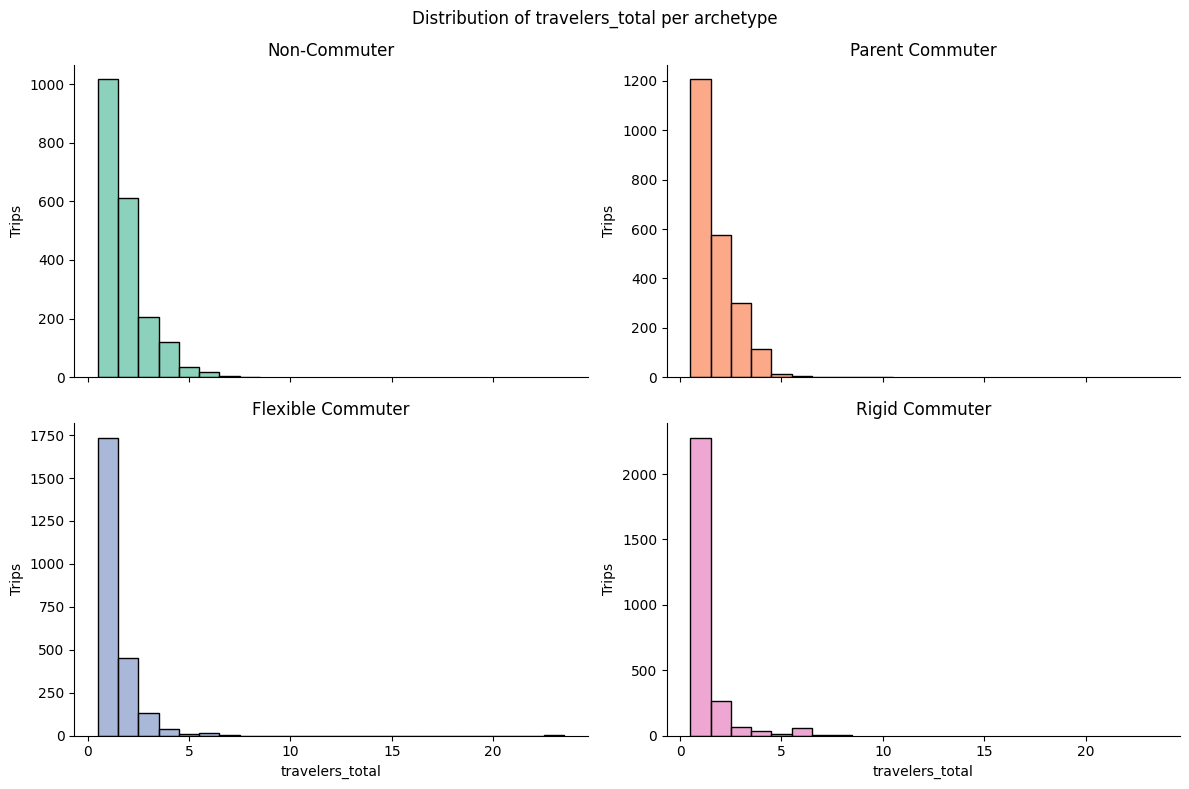

In [97]:
traveler_records = [
    {"archetype": profile.archetype.value, "travelers_total": trip.travelers_total}
    for profile in filtered_profiles
    for trip in profile.trips
]
traveler_df = pd.DataFrame(traveler_records)

archetype_order = [archetype.value for archetype in Archetype]
palette = sns.color_palette("Set2", n_colors = len(archetype_order))

fig, axes = plt.subplots(2, 2, figsize = (12, 8), sharex = True)
for index, archetype_value in enumerate(archetype_order):
    ax = axes[index // 2][index % 2]
    subset = traveler_df[traveler_df["archetype"] == archetype_value]["travelers_total"]
    sns.histplot(subset, discrete = True, color = palette[index], ax = ax)
    ax.set_title(archetype_value)
    ax.set_xlabel("travelers_total")
    ax.set_ylabel("Trips")
sns.despine(fig = fig)
fig.suptitle("Distribution of travelers_total per archetype")
plt.tight_layout()
plt.show()